# 05 - Model Training & Comparison

This notebook demonstrates the model training pipeline:
1. Load preprocessed and feature-selected data
2. Run Nested CV: MI-only baseline vs MI→PSO→XGBoost
3. Compare all 6 models (LR, RF, SVM, XGBoost, LightGBM, CatBoost)
4. Save results

> **Critical Rule:** All feature selection and preprocessing happen
> INSIDE cross-validation folds. Test data remains untouched.

In [13]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

import config
from src.io import save_table, save_figure, logger
from src.pipeline import evaluate_nested_cv, compare_models_nested_cv, evaluate_final_model
from src.models import make_xgb, xgb_safe_frame, requires_xgb_safe
from src.feature_selection import transform_selected
from src.visualization import setup_style, plot_model_comparison_bar

setup_style()

## Step 1: Load Training Data

In [14]:
X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]

print(f"Train shape: {X_train.shape}")
print(f"Positive rate: {y_train.mean():.2%}")

Train shape: (300, 19019)
Positive rate: 13.67%


## Step 2: Nested CV — MI-only vs MI→PSO→XGBoost

This evaluates whether Binary PSO feature selection improves
over Mutual Information alone, using nested cross-validation.

- **Outer CV:** 5-fold stratified split for unbiased evaluation
- **Inner CV:** 3-fold stratified split for PSO fitness evaluation
- **Leakage Prevention:** All selection fitted only on training folds

In [15]:
nested_results = evaluate_nested_cv(
    X_train,
    y_train,
    outer_splits=config.OUTER_SPLITS,
    variance_threshold=config.VARIANCE_THRESHOLD,
    mi_top_k=config.MI_TOP_K,
    pso_final_k=config.PSO_FINAL_K,
    run_pso=True,
    random_state=config.RANDOM_STATE,
)

save_table(nested_results, "nested_cv_results.csv", index=False)
print("\nNested CV Results:")
print(nested_results.to_string(index=False))

2026-08-14 20:29:54 | INFO     | prostate_bcr | Filter selector: 18987 variance → 200 MI features
2026-08-14 20:29:58 | INFO     | prostate_bcr | PSO: 12 particles, 10 iterations, target 30 features, alpha=0.0010
2026-08-14 20:30:15 | INFO     | prostate_bcr |   PSO iter 5/10: best Fitness=0.8765 (Raw AUC ≈ 0.9065)
2026-08-14 20:30:32 | INFO     | prostate_bcr |   PSO iter 10/10: best Fitness=0.8773 (Raw AUC ≈ 0.9073)
2026-08-14 20:30:32 | INFO     | prostate_bcr | PSO selected 30 features with final fitness=0.8773
2026-08-14 20:30:32 | INFO     | prostate_bcr | Fold 1: MI AUC=0.6226 | PSO AUC=0.6034 | PSO features=30
2026-08-14 20:31:06 | INFO     | prostate_bcr | Filter selector: 18987 variance → 200 MI features
2026-08-14 20:31:10 | INFO     | prostate_bcr | PSO: 12 particles, 10 iterations, target 30 features, alpha=0.0010
2026-08-14 20:31:26 | INFO     | prostate_bcr |   PSO iter 5/10: best Fitness=0.8137 (Raw AUC ≈ 0.8437)
2026-08-14 20:31:43 | INFO     | prostate_bcr |   PSO ite


Nested CV Results:
 fold  n_var_features  n_mi_features  n_pso_features   mi_auc  pso_inner_fitness  pso_auc
    1           18987            200              30 0.622596           0.877334 0.603365
    2           18987            200              30 0.649038           0.844835 0.603365
    3           18986            200              30 0.689904           0.829464 0.586538
    4           18986            200              30 0.656250           0.835613 0.783654
    5           18987            200              30 0.795207           0.822540 0.821351


## Step 3: Nested CV Summary

Summary Statistics:
           mean     std     min     max
mi_auc   0.6826  0.0674  0.6226  0.7952
pso_auc  0.6797  0.1131  0.5865  0.8214


2026-08-14 20:35:05 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\nested_cv_comparison.png


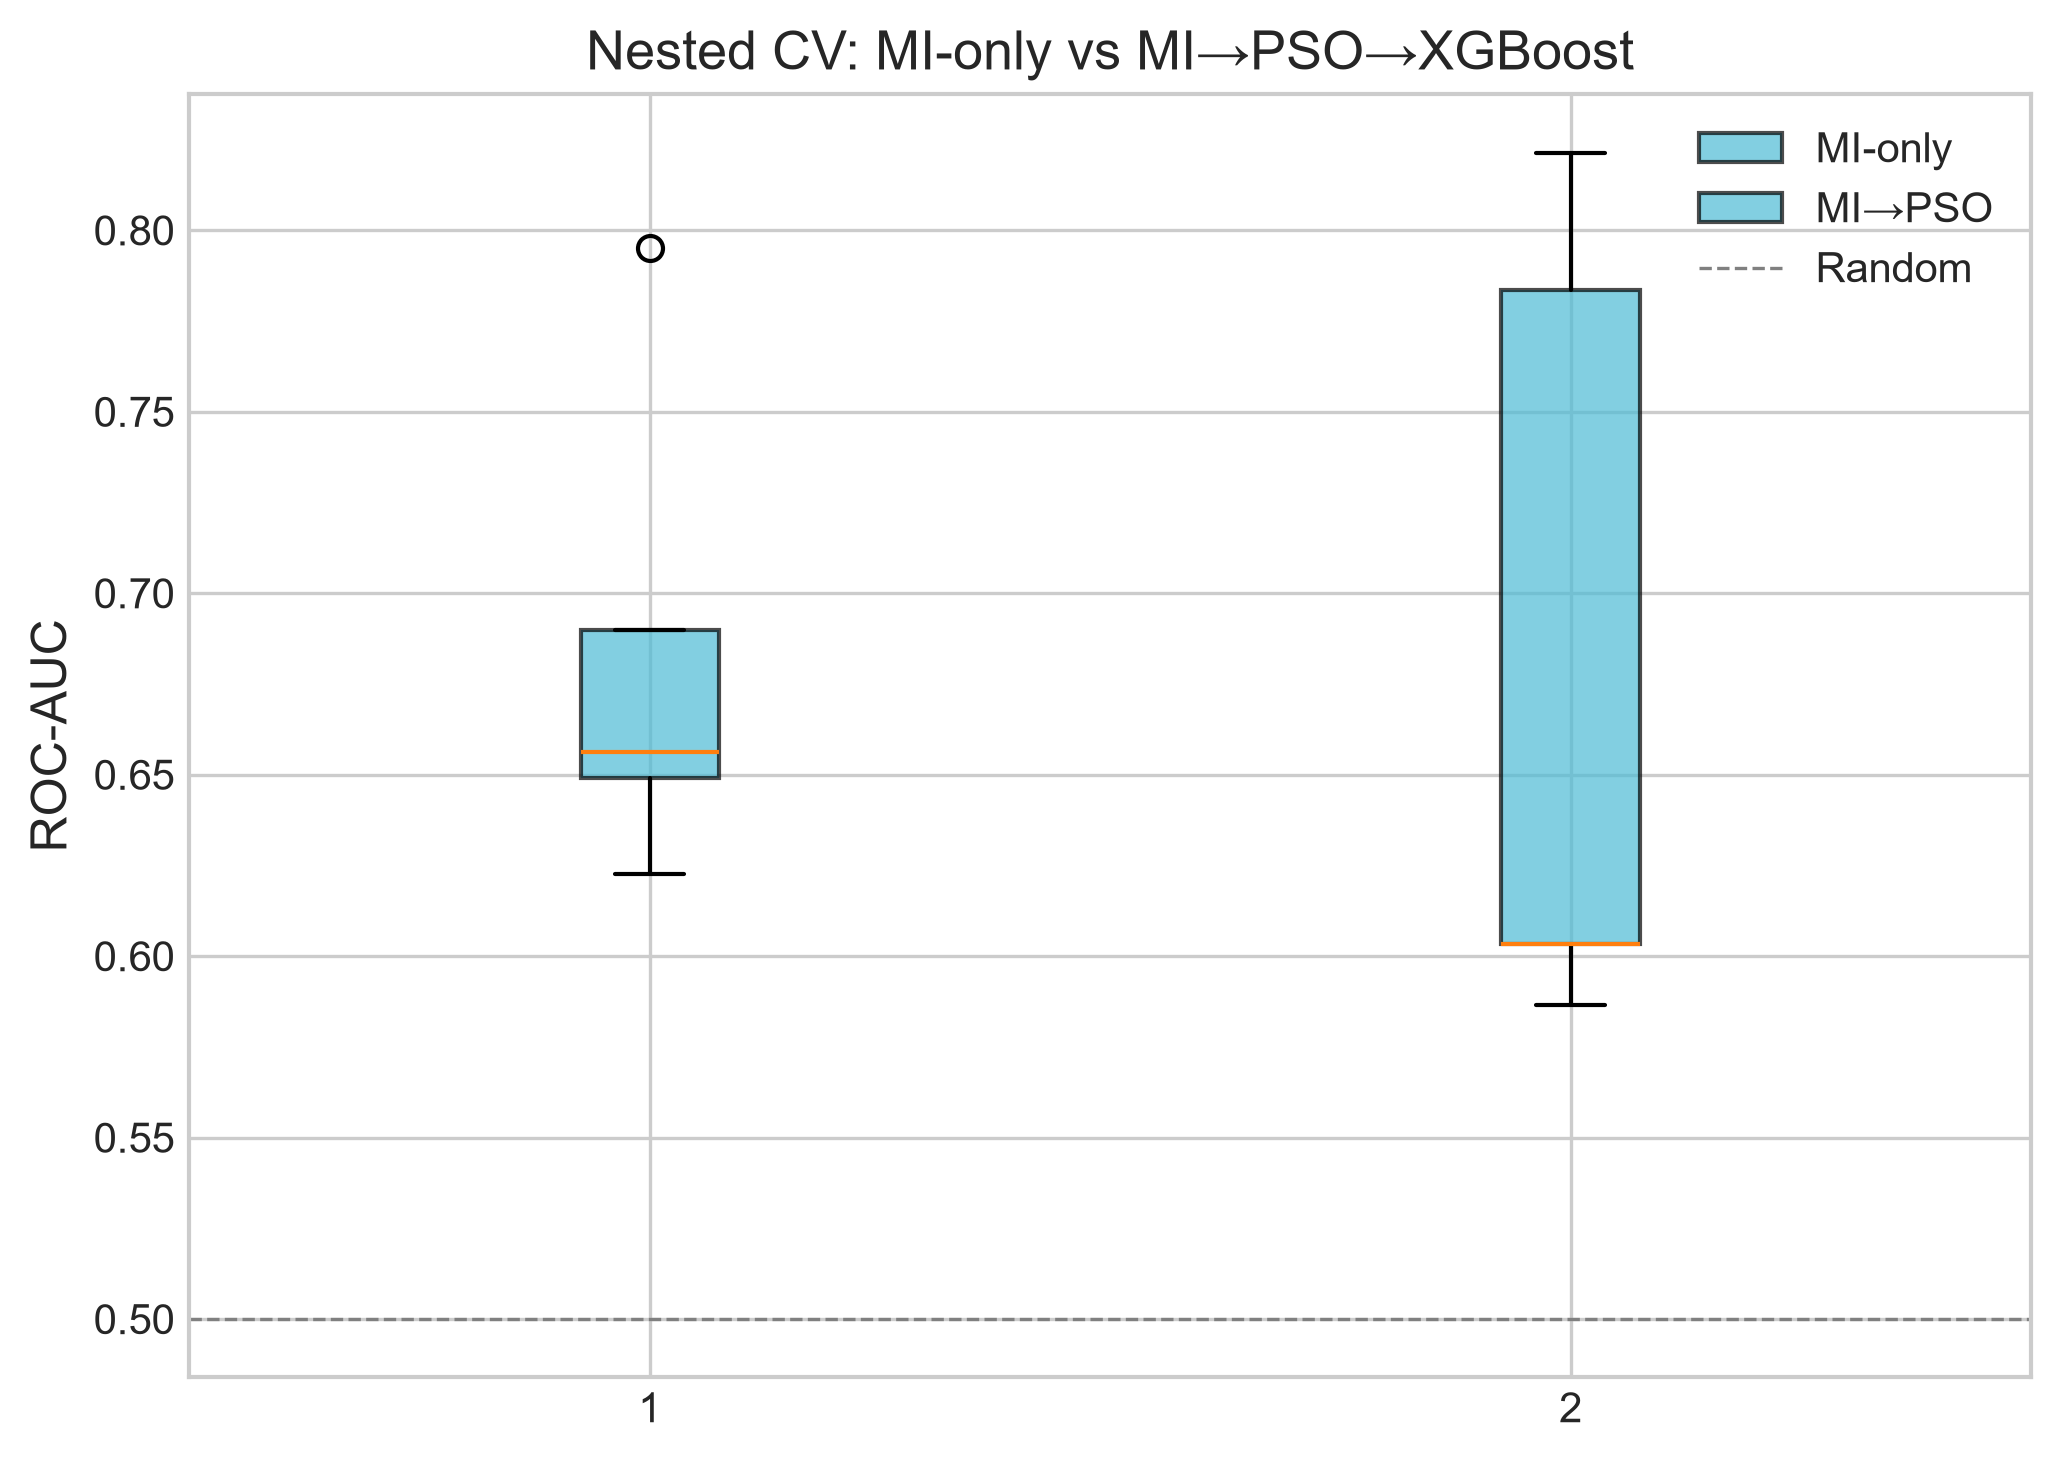

In [16]:
summary = nested_results.describe().T.loc[["mi_auc", "pso_auc"]]
print("Summary Statistics:")
print(summary[["mean", "std", "min", "max"]].round(4))

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([nested_results["mi_auc"], nested_results["pso_auc"]],
           label=["MI-only", "MI→PSO"], patch_artist=True,
           boxprops=dict(facecolor="#4DBBD5", alpha=0.7))
ax.set_ylabel("ROC-AUC")
ax.set_title("Nested CV: MI-only vs MI→PSO→XGBoost")
ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8, label="Random")
ax.legend()
plt.tight_layout()
save_figure(fig, "nested_cv_comparison.png")
plt.show()

## Step 4: Multi-Model Comparison

Compare all 6 registered models using outer CV on the final
PSO-selected features.

In [17]:
# Load final selected features
selected_features_df = pd.read_csv(config.TABLES_DIR / "selected_features.csv")
selected_features = selected_features_df["feature"].tolist()

print(f"Using {len(selected_features)} PSO-selected features for model comparison")

model_comparison = compare_models_nested_cv(
    X_train,
    y_train,
    selected_features,
    outer_splits=config.OUTER_SPLITS,
    random_state=config.RANDOM_STATE,
)

save_table(model_comparison, "model_comparison_results.csv", index=False)
print("\nModel Comparison Results:")
print(model_comparison.pivot_table(index="model", values="auc", aggfunc=["mean", "std"]).round(4))

Using 30 PSO-selected features for model comparison


2026-08-14 20:35:05 | INFO     | prostate_bcr | Built model: Logistic Regression
2026-08-14 20:35:05 | INFO     | prostate_bcr |   Fold 1 | Logistic Regression: AUC=0.5793
2026-08-14 20:35:05 | INFO     | prostate_bcr | Built model: Random Forest
2026-08-14 20:35:06 | INFO     | prostate_bcr |   Fold 1 | Random Forest: AUC=0.7260
2026-08-14 20:35:06 | INFO     | prostate_bcr | Built model: SVM
d:\Prostate_BCR\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
2026-08-14 20:35:06 | INFO     | prostate_bcr |   Fold 1 | SVM: AUC=0.6779
2026-08-14 20:35:06 | INFO     | prostate_bcr | Built model: XGBoost
2026-08-14 20:35:06 | INFO     | prostate_bcr |   Fold 1 | XGBoost: AUC=0.8005
2026-08-14 20:35:06 | INFO     | prostate_bcr | Built model: LightGBM
2026-08-14 20:35:06 | INFO     | prosta


Model Comparison Results:
                       mean     std
                        auc     auc
model                              
CatBoost             0.8598  0.0920
LightGBM             0.8758  0.0296
Logistic Regression  0.7686  0.1078
Random Forest        0.8647  0.0823
SVM                  0.7992  0.0818
XGBoost              0.8788  0.0486


## Step 5: Model Comparison Visualization

In [18]:
# Aggregate results for plotting
model_summary = model_comparison.groupby("model")["auc"].mean().reset_index()
model_summary.columns = ["model", "roc_auc"]

fig = plot_model_comparison_bar(
    model_summary,
    metrics_to_show=["roc_auc"],
    filename="model_comparison_bar.png",
)
plt.show()

2026-08-14 20:35:11 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\model_comparison_bar.png
2026-08-14 20:35:11 | INFO     | prostate_bcr | Model comparison bar chart generated


## Step 6: Per-Fold AUC by Model

2026-08-14 20:35:11 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\per_fold_auc_by_model.png


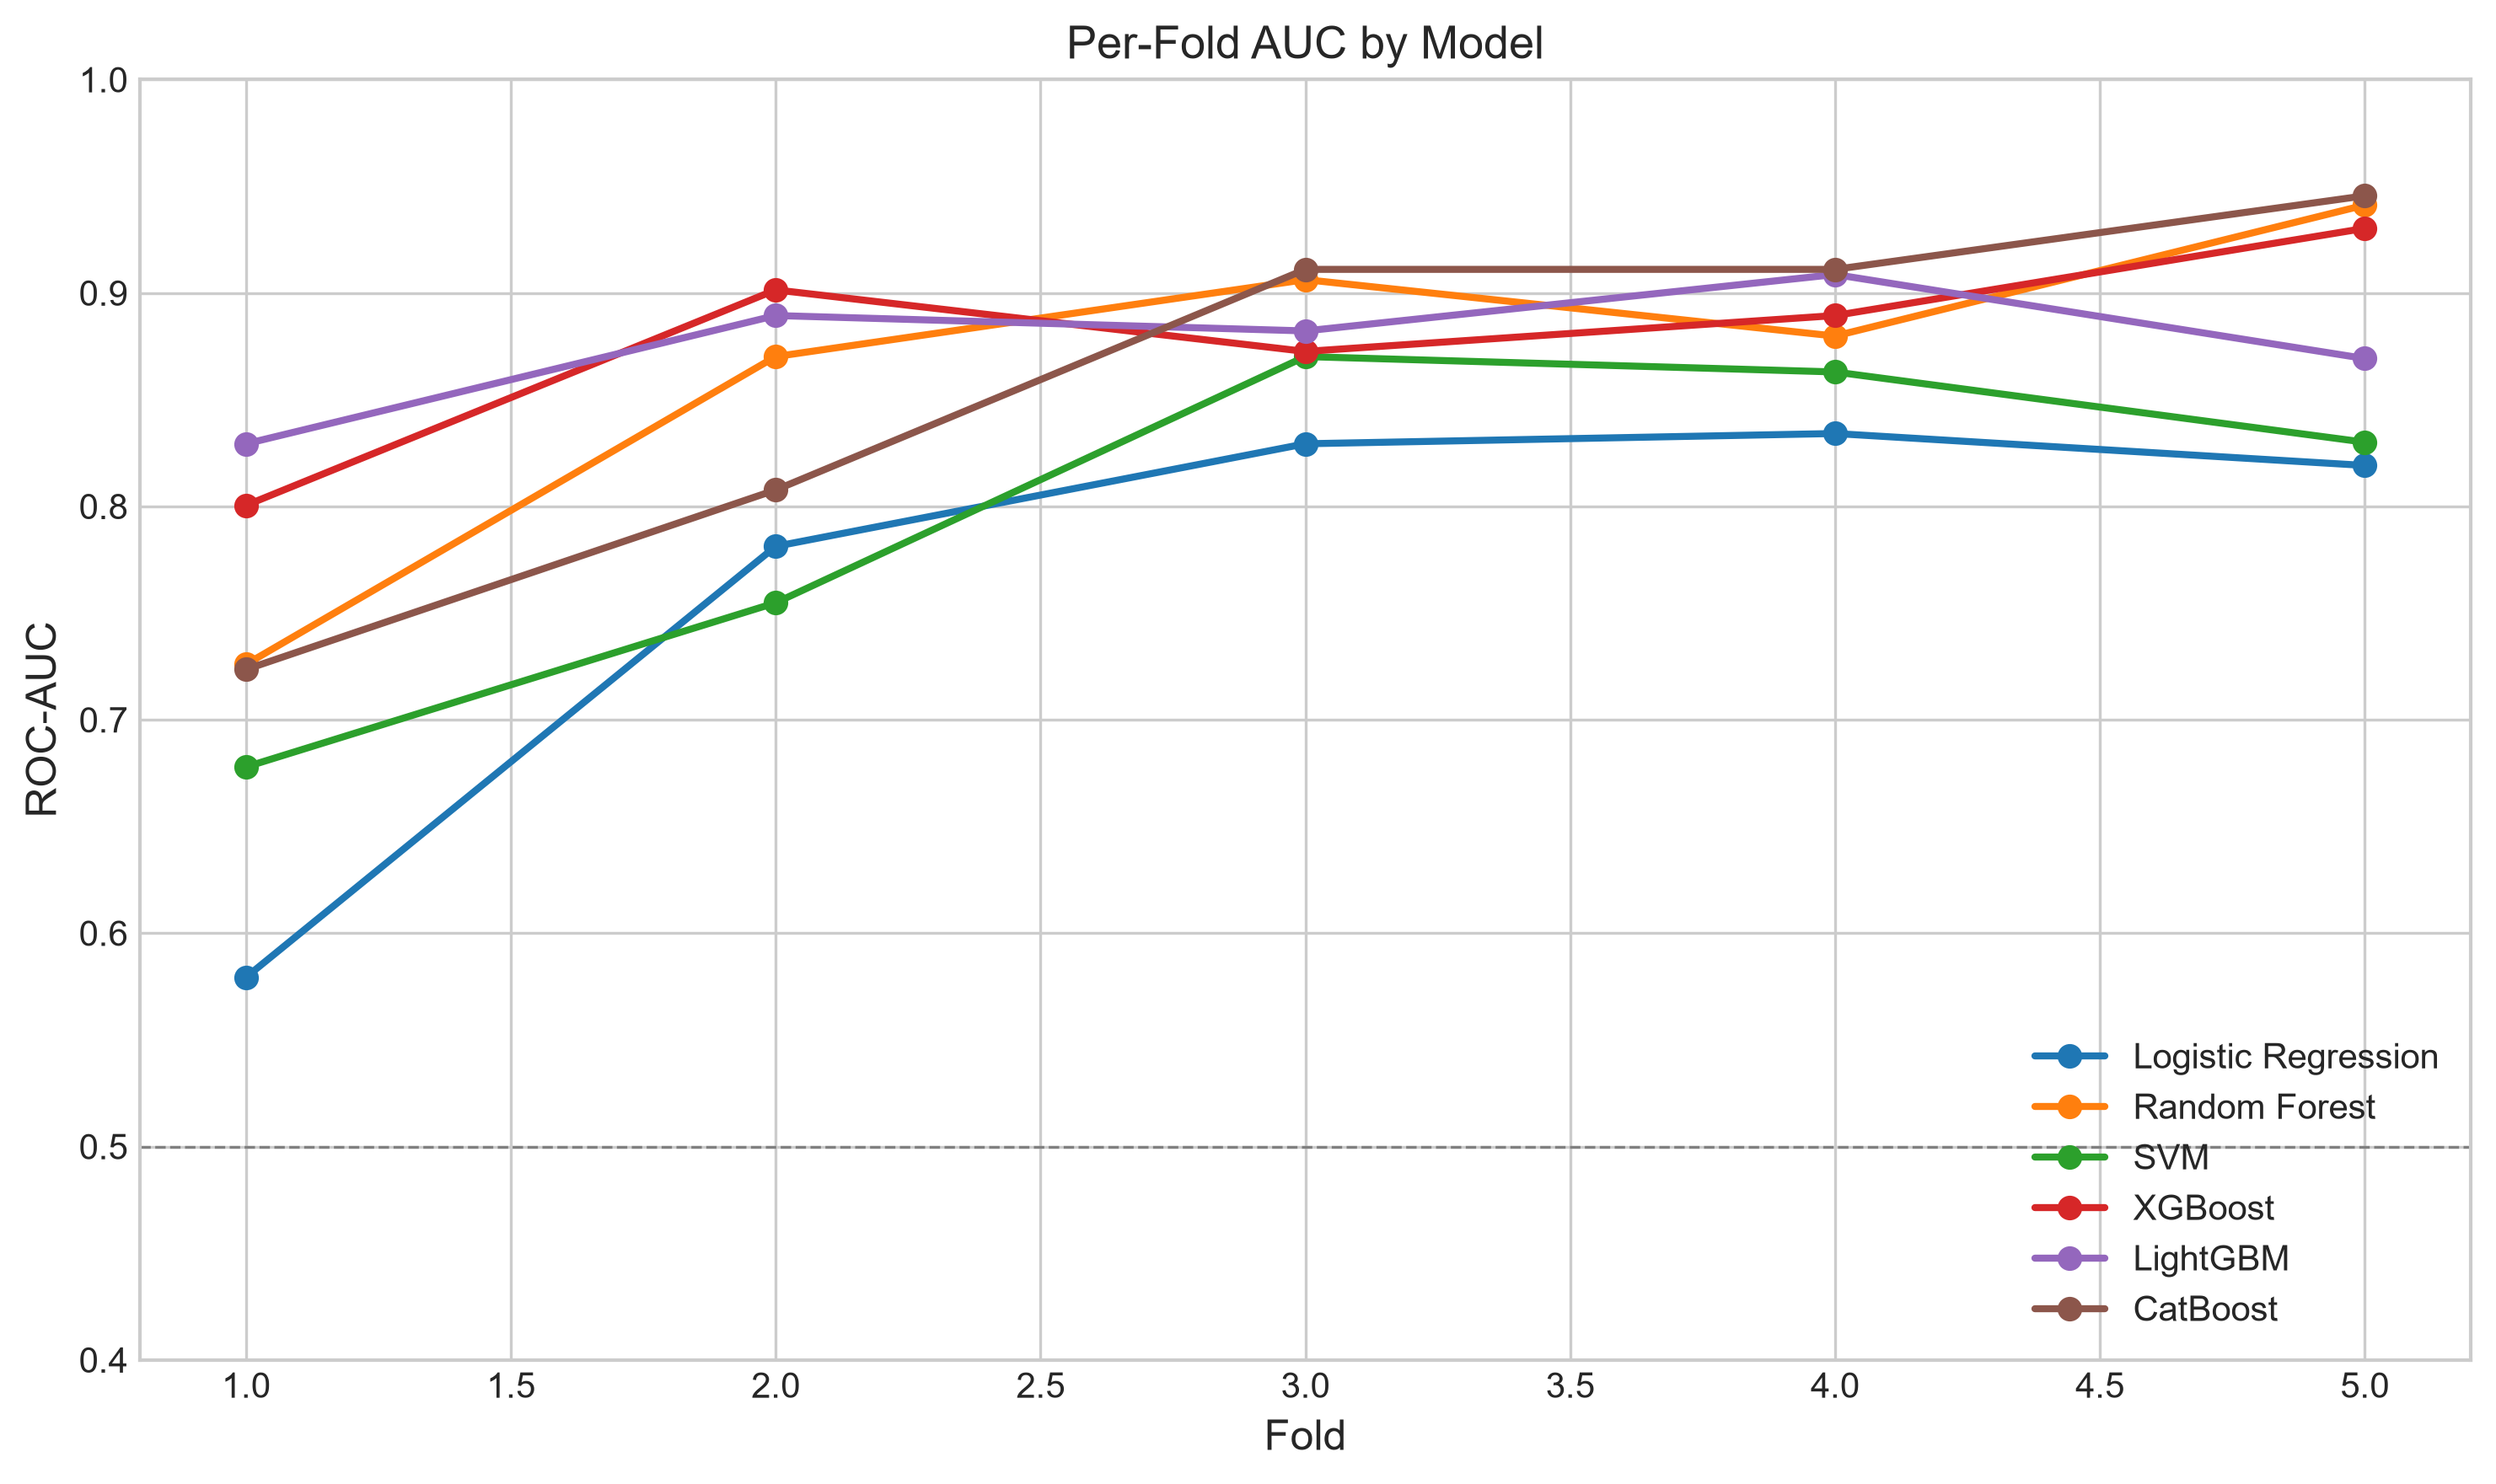

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for model_name in model_comparison["model"].unique():
    subset = model_comparison[model_comparison["model"] == model_name]
    ax.plot(subset["fold"], subset["auc"], marker="o", label=model_name, linewidth=2)

ax.set_xlabel("Fold")
ax.set_ylabel("ROC-AUC")
ax.set_title("Per-Fold AUC by Model")
ax.legend(loc="lower right", framealpha=0.9)
ax.set_ylim([0.4, 1.0])
ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
save_figure(fig, "per_fold_auc_by_model.png")
plt.show()

## Step 7: Train Final Model on Full Training Set

> **Leakage Prevention:** The final model is trained on the full
> training set using PSO features that were selected inside CV folds.
> Test data is NOT used for training.

In [25]:
import pandas as pd
from src.models import tune_model
from src.feature_selection import create_engineered_features

# 1. Load PSO-selected features (فقط لیست ۳۰ تای اولیه)
selected_features_df = pd.read_csv(config.TABLES_DIR / "selected_features.csv")
pso_features = selected_features_df["feature"].tolist()
print(f"Loaded {len(pso_features)} base PSO features")

# 2. Load Raw Data
X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]
X_test = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

# 3. Apply Feature Engineering to FULL data first
# این تابع ستون‌های جدید (Gleason_Total, PSA_Score, ...) را می‌سازد
print("Applying feature engineering...")
X_train_eng, engineered_cols = create_engineered_features(X_train)
X_test_eng, _ = create_engineered_features(X_test)

# 4. Combine PSO features + Engineered features
# ما هم ۳۰ ویژگی PSO را می‌خواهیم و هم ویژگی‌های جدید مهندسی شده را
final_features = pso_features + engineered_cols

# اطمینان از اینکه همه ویژگی‌ها در دیتاست وجود دارند
final_features = [f for f in final_features if f in X_train_eng.columns]

print(f"Total features for training: {len(final_features)} (30 PSO + {len(engineered_cols)} Engineered)")

# 5. Prepare final matrices
X_train_final = X_train_eng[final_features].copy()
X_test_final = X_test_eng[final_features].copy()

print(f"Train shape: {X_train_final.shape}, positives={int(y_train.sum())}")
print(f"Test shape: {X_test_final.shape}, positives={int(y_test.sum())}")

# 6. Tune and Train
best_model, search = tune_model(
    "XGBoost",
    X_train_final,
    y_train,
    config.XGBOOST_SEARCH_SPACE,
)

print(f"\nFinal model tuned & trained.")
print(f"   Best CV AUC: {search.best_score_:.4f}")
print(f"   Best params: {search.best_params_}")

# ذخیره لیست نهایی ویژگی‌ها (بسیار مهم برای نوت‌بوک ۰۶)
pd.DataFrame({"feature": final_features}).to_csv(
    config.TABLES_DIR / "selected_features_final.csv", index=False
)
print("   Saved 'selected_features_final.csv' with engineered features.")

# ذخیره مدل و داده تست
import joblib
joblib.dump(best_model, config.MODELS_DIR / "best_model_xgboost.joblib")
X_test_final.to_csv(config.PROCESSED_DIR / "X_test_selected.csv", index=False)
y_test.to_csv(config.PROCESSED_DIR / "y_test.csv", index=False)
print("   Model and Test Data saved.")

Loaded 30 base PSO features
Applying feature engineering...


2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: Gleason_Total, High_Risk_Gleason
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: Margin_x_LymphNode
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: T_Stage_Risk
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: PSA_Pathway_Score (from 7 genes)
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: AR_Signaling_Score (from 8 genes)
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: Proliferation_Score (from 7 genes)
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: Gleason_Total, High_Risk_Gleason
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: Margin_x_LymphNode
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: T_Stage_Risk
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: PSA_Pathway_Score (from 7 genes)
2026-08-14 20:59:28 | INFO     | prostate_bcr | Engineered: AR_Signaling_Score (from 8 genes)
2026-08-14 20:59:28 | INFO     | prostate

Total features for training: 37 (30 PSO + 7 Engineered)
Train shape: (300, 37), positives=41
Test shape: (129, 37), positives=17


2026-08-14 20:59:35 | INFO     | prostate_bcr | Tuned 'XGBoost': best CV roc_auc = 0.8698
2026-08-14 20:59:35 | INFO     | prostate_bcr | Best params: {'subsample': 0.65, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.65}



Final model tuned & trained.
   Best CV AUC: 0.8698
   Best params: {'subsample': 0.65, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.65}
   Saved 'selected_features_final.csv' with engineered features.
   Model and Test Data saved.


In [20]:

# from src.models import tune_model

# # Load PSO-selected features
# selected_features_df = pd.read_csv(config.TABLES_DIR / "selected_features.csv")
# final_pso_features = selected_features_df["feature"].tolist()
# print(f"Loaded {len(final_pso_features)} PSO-selected features")

# # ── Fix: re-load training data for robustness (no dependency on prior cells) ──
# X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
# y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]
# print(f"Train shape: {X_train.shape}, positives={int(y_train.sum())}")

# # Load test data
# X_test = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
# y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]
# print(f"Test shape: {X_test.shape}, positives={int(y_test.sum())}")

# # Prepare final feature matrices
# X_train_final = X_train[final_pso_features].copy()
# X_test_final = X_test[final_pso_features].copy()

# # ── NEW: Tune hyperparameters on training data ONLY (RandomizedSearchCV) ──
# best_model, search = tune_model(
#     "XGBoost",
#     X_train_final,
#     y_train,
#     config.XGBOOST_SEARCH_SPACE,
# )

# print(f"\n Final model tuned & trained on {len(X_train_final)} samples")
# print(f"   Features used: {len(final_pso_features)}")
# print(f"   Best CV AUC: {search.best_score_:.4f}")
# print(f"   Best params: {search.best_params_}")

# pd.DataFrame([search.best_params_]).to_csv(
#     config.TABLES_DIR / "best_hyperparameters.csv", index=False
# )
# print("   Best hyperparameters saved → best_hyperparameters.csv")


## Step 8: Save Model and Test Data

In [28]:


import joblib

# Ensure directories exist
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
config.TABLES_DIR.mkdir(parents=True, exist_ok=True)
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save the trained XGBoost model
model_path = config.MODELS_DIR / "best_model_xgboost.joblib"
joblib.dump(best_model, model_path)
print(f" Model saved to {model_path}")

# 2. Save the selected features list
features_path = config.TABLES_DIR / "selected_features.csv"
pd.DataFrame({"feature": final_pso_features}).to_csv(features_path, index=False)
print(f" Selected features saved to {features_path}")

# 3. Save the held-out test data (required for SHAP and evaluation)
X_test_final.to_csv(config.PROCESSED_DIR / "X_test_selected.csv", index=False)
y_test.to_csv(config.PROCESSED_DIR / "y_test.csv", index=False)
print(f" Test data saved to {config.PROCESSED_DIR}")

 Model saved to D:\Prostate_BCR\core\outputs\models\best_model_xgboost.joblib
 Selected features saved to D:\Prostate_BCR\core\outputs\tables\selected_features.csv
 Test data saved to D:\Prostate_BCR\core\data\processed
